In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
DATA_PATH = r'C:\Users\manur\OneDrive\Documents\Multi_Crop_Ranking_\Multi_Crop_Ranking\Notebooks\Models\Crop_training_data_FULL_F1.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

# Basic info
df.info()
df.describe()

Shape: (2100, 14)
<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crop               2100 non-null   str    
 1   temperature        2100 non-null   float64
 2   rainfall           2100 non-null   float64
 3   sunshine_hours     2100 non-null   float64
 4   ph                 2100 non-null   float64
 5   organic_carbon     2100 non-null   float64
 6   cec                2100 non-null   float64
 7   awc                2100 non-null   float64
 8   bulk_density       2100 non-null   float64
 9   rooting_depth_m    2100 non-null   float64
 10  texture            2100 non-null   str    
 11  texture_code       2100 non-null   int64  
 12  suitability        2100 non-null   float64
 13  suitability_class  2100 non-null   str    
dtypes: float64(10), int64(1), str(3)
memory usage: 229.8 KB


,temperature,rainfall,sunshine_hours,ph,organic_carbon,cec,awc,bulk_density,rooting_depth_m,texture_code,suitability
count,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000
mean,27.483838,2595.260930,7.485613,5.075321,3.582028,14.075979,0.027378,1.299567,0.900688,3.943333,0.774260
std,2.587973,172.675391,0.875834,0.293225,0.774731,4.052241,0.009997,0.135175,0.341623,2.008113,0.080141
min,23.005125,2300.323314,6.000558,4.575084,2.221522,7.001687,0.010000,1.064001,0.301457,1.000000,0.504000
25%,25.361581,2445.988061,6.709242,4.821311,2.897531,10.532726,0.018823,1.184760,0.618330,2.000000,0.718750
50%,27.464027,2592.399093,7.481220,5.072574,3.596631,14.224267,0.027371,1.300998,0.905471,4.000000,0.769000
75%,29.699400,2746.084392,8.265386,5.324427,4.229305,17.602903,0.036012,1.417927,1.184979,6.000000,0.832000
max,31.998467,2899.980409,8.995621,5.588575,4.929800,20.997522,0.044984,1.531980,1.499816,7.000000,0.989000


In [ ]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values (top):')
print(missing[missing > 0])

Missing values (top):
Series([], dtype: int64)


In [ ]:
# Duplicates
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


suitability_class
Suitable      1267
Unsuitable     833
Name: count, dtype: int64


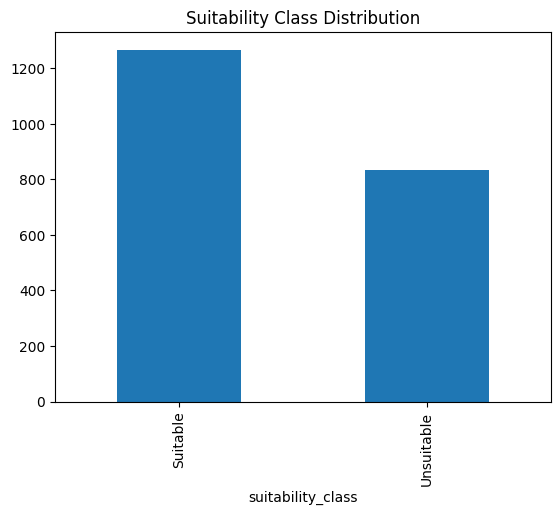

In [ ]:
# Target distribution
target_counts = df['suitability_class'].value_counts()
print(target_counts)
target_counts.plot(kind='bar')
plt.title('Suitability Class Distribution')
plt.show()

In [ ]:
# Summary statistics for numeric columns
df.describe()

,temperature,rainfall,sunshine_hours,ph,organic_carbon,cec,awc,bulk_density,rooting_depth_m,texture_code,suitability
count,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000,2100.000000
mean,27.483838,2595.260930,7.485613,5.075321,3.582028,14.075979,0.027378,1.299567,0.900688,3.943333,0.774260
std,2.587973,172.675391,0.875834,0.293225,0.774731,4.052241,0.009997,0.135175,0.341623,2.008113,0.080141
min,23.005125,2300.323314,6.000558,4.575084,2.221522,7.001687,0.010000,1.064001,0.301457,1.000000,0.504000
25%,25.361581,2445.988061,6.709242,4.821311,2.897531,10.532726,0.018823,1.184760,0.618330,2.000000,0.718750
50%,27.464027,2592.399093,7.481220,5.072574,3.596631,14.224267,0.027371,1.300998,0.905471,4.000000,0.769000
75%,29.699400,2746.084392,8.265386,5.324427,4.229305,17.602903,0.036012,1.417927,1.184979,6.000000,0.832000
max,31.998467,2899.980409,8.995621,5.588575,4.929800,20.997522,0.044984,1.531980,1.499816,7.000000,0.989000


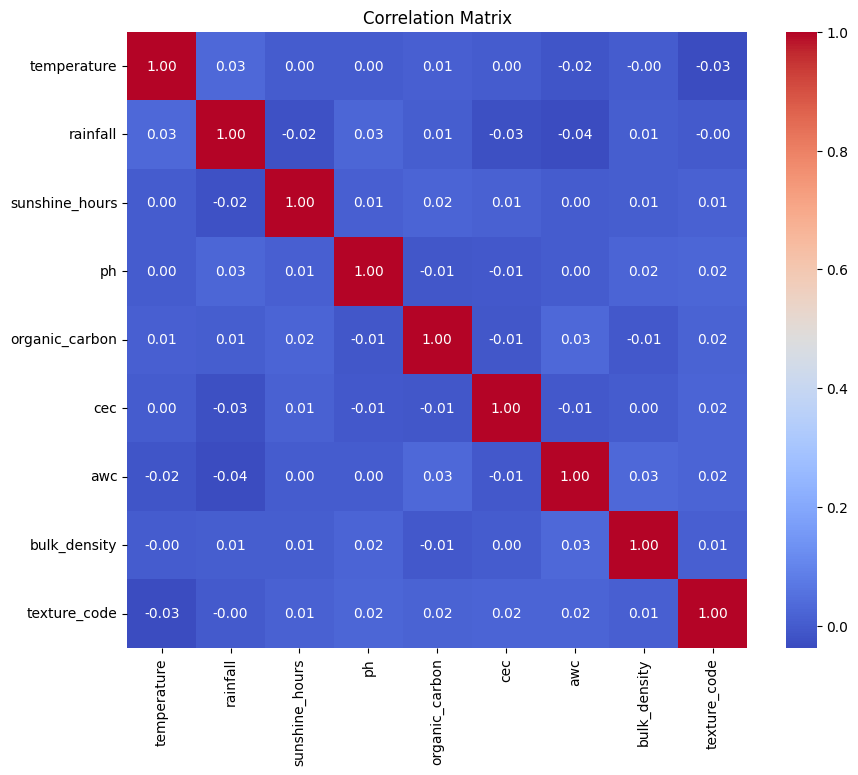

Correlation with target (point-biserial):
organic_carbon: -0.276
texture_code: -0.107
cec: 0.103
rainfall: -0.093
awc: -0.075
ph: 0.020
temperature: -0.010
sunshine_hours: 0.008
bulk_density: -0.006


In [ ]:
# correlation matrix
numeric_cols = ['temperature','rainfall','sunshine_hours','ph',
                'organic_carbon','cec','awc','bulk_density','texture_code']
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Check correlations with target
from scipy.stats import pointbiserialr
target_binary = df['suitability_class'].map({'Suitable':1, 'Unsuitable':0})
corr_with_target = {}
for f in numeric_cols:
    corr_with_target[f] = pointbiserialr(target_binary, df[f])[0]
print("Correlation with target (point-biserial):")
for k,v in sorted(corr_with_target.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{k}: {v:.3f}")

In [ ]:
# Define environmental columns (used for scenario grouping)
ENV_COLS = [
    'temperature', 'rainfall', 'sunshine_hours',
    'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'texture_code'
]
display('Environmental columns:', ENV_COLS)

'Environmental columns:'

['temperature',
 'rainfall',
 'sunshine_hours',
 'ph',
 'organic_carbon',
 'cec',
 'awc',
 'bulk_density',
 'texture_code']

In [ ]:
# Create scenario groups (to prevent leakage)
rounded = df[ENV_COLS].round(2)
df['scenario_id'] = pd.util.hash_pandas_object(rounded, index=False).astype('int64')
print('Unique scenarios:', df['scenario_id'].nunique())

Unique scenarios: 2100


In [ ]:
# Save a copy
try:
    df.to_csv(r'C:\Users\manur\OneDrive\Documents\Multi_Crop_Ranking_\Multi_Crop_Ranking\Data\df_with_scenario.csv', index=False)
except Exception as e:
    print(f"Error occurred while saving the file: {e}")
else:
    print("File saved successfully !")

File saved successfully !
